### Import Library

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dashboard import sales_data,Missing_values,Duplicate_Values

#### Total Sales by Region

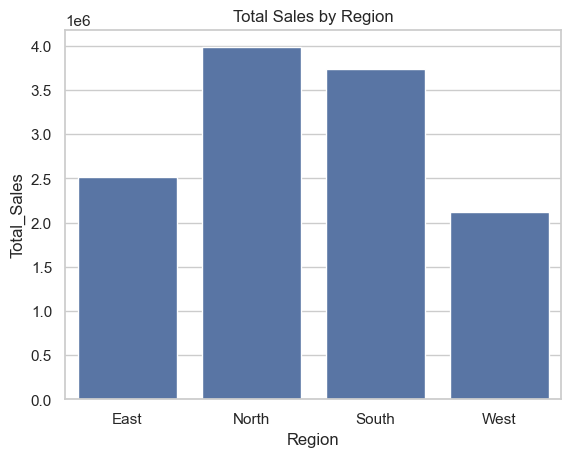

In [7]:
# Convert Date
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Style
sns.set(style="whitegrid")

# Total sales by region
region_sales = sales_data.groupby('Region')['Total_Sales'].sum().reset_index()

sns.barplot(data=region_sales, x='Region', y='Total_Sales')
plt.title("Total Sales by Region")
plt.show()

#### Statistical Visualizations

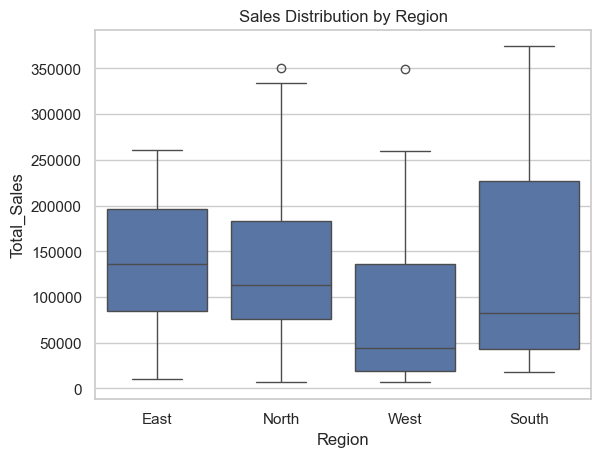

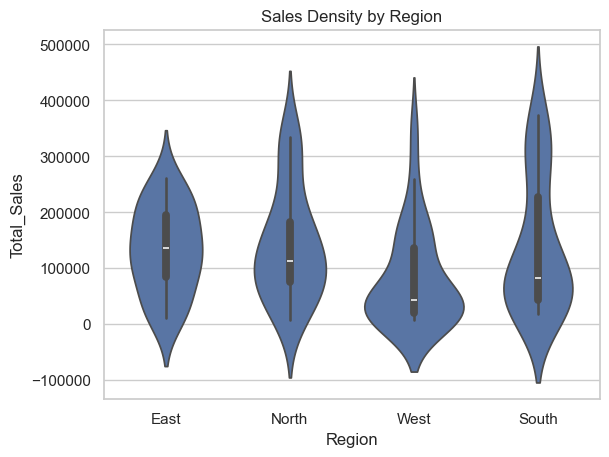

In [8]:
# Box plot
sns.boxplot(data=sales_data, x='Region', y='Total_Sales')
plt.title("Sales Distribution by Region")
plt.show()

# Violin plot
sns.violinplot(data=sales_data, x='Region', y='Total_Sales')
plt.title("Sales Density by Region")
plt.show()

#### Heatmaps & Correlation

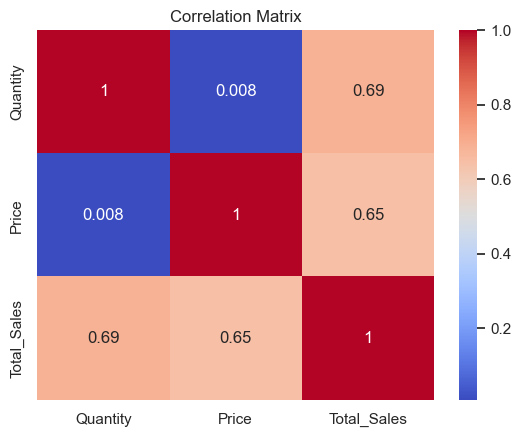

In [9]:
# Correlation
corr = sales_data[['Quantity', 'Price', 'Total_Sales']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Multi-plot Dashboard

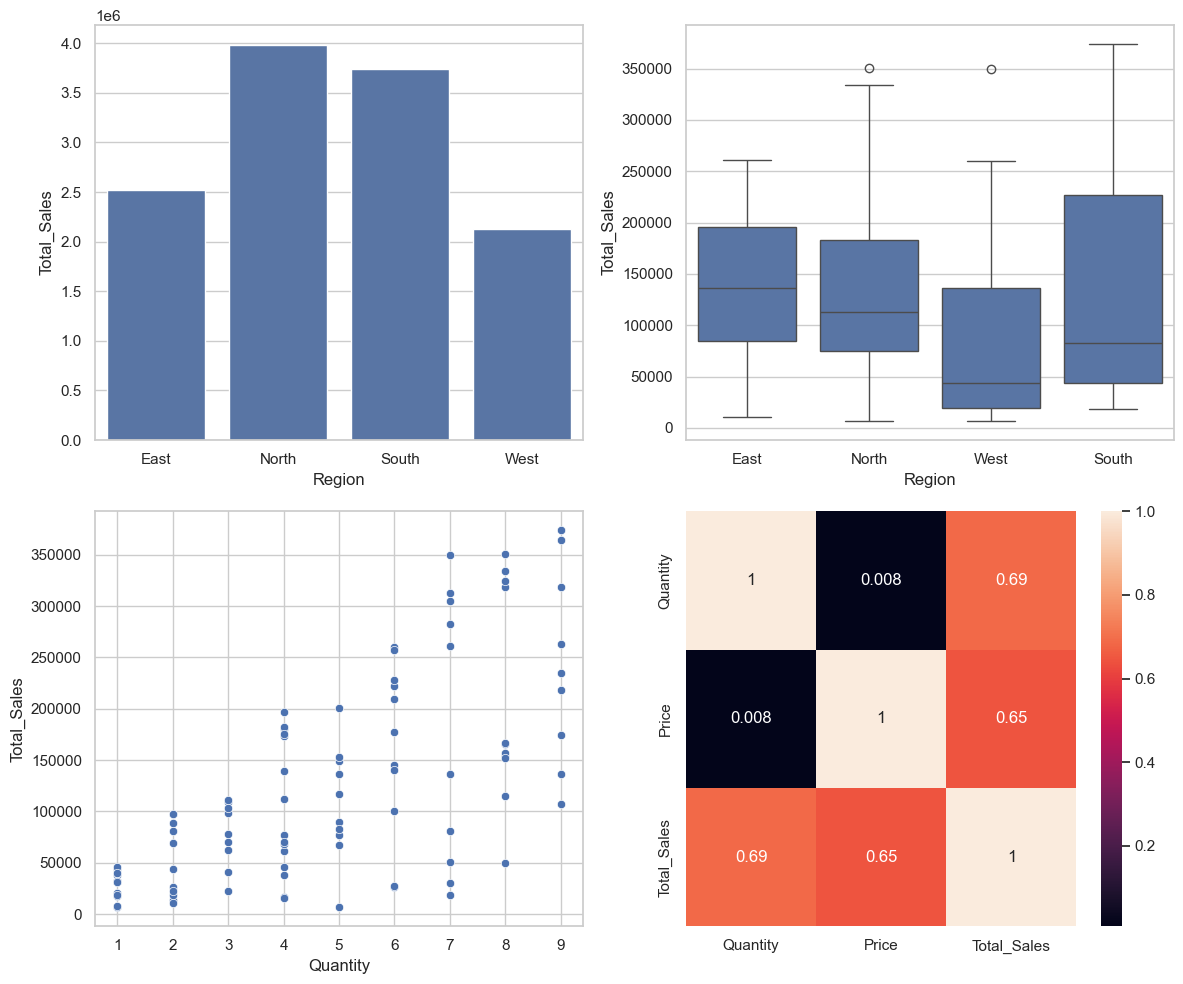

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1. Sales by Region
sns.barplot(data=region_sales, x='Region', y='Total_Sales', ax=axes[0,0])

# 2. Sales Distribution
sns.boxplot(data=sales_data, x='Region', y='Total_Sales', ax=axes[0,1])

# 3. Quantity vs Sales
sns.scatterplot(data=sales_data, x='Quantity', y='Total_Sales', ax=axes[1,0])

# 4. Correlation
sns.heatmap(corr, annot=True, ax=axes[1,1])

plt.tight_layout()
plt.show()

#### Interactive Visualizations

In [14]:
import plotly.express as px

# Interactive bar
fig = px.bar(region_sales, x='Region', y='Total_Sales',
             title="Interactive Sales by Region")
fig.show()

# Scatter with hover
fig = px.scatter(sales_data, x='Quantity', y='Total_Sales',
                 color='Region',
                 hover_data=['Product', 'Customer_ID'])
fig.show()

# Dashboard Integration

In [20]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=2, cols=2,
                   subplot_titles=("Region Sales", "Sales Dist",
                                   "Scatter"))

# Add plots
fig.add_trace(go.Bar(x=region_sales['Region'], y=region_sales['Total_Sales']), row=1, col=1)
fig.add_trace(go.Box(y=sales_data['Total_Sales']), row=1, col=2)
fig.add_trace(go.Scatter(x=sales_data['Quantity'], y=sales_data['Total_Sales'], mode='markers'), row=2, col=1)

fig.update_layout(height=700, title="Sales Dashboard")
fig.show()

#### Polish & Presentation

In [21]:
fig.write_html("sales_dashboard.html")